In [ ]:
# cargamos librerias para explorar y visualizar los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline
# Evita abrir graficos en otras pestañas

In [ ]:
# Cargamos el dataset limpio
df = pd.read_csv('/content/CLEAN DATA 3-atenciones_oficina_publica_de_empleo_ope.csv')

In [ ]:
df.head(100)

,Unnamed: 0,edad,sexo,etnia,discapacidad,victima,población_campesina,estado_civil,nivel_escolaridad,cabeza_de_hogar,orientación_sexual,caracterizacion_ciudadano,empleado,estrato,barrio_vereda_ciudadano,comuna_ciudadano,nombre_del_beneficio_otorgado,fecha_de_beneficio
0,0,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
1,1,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
2,2,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
3,3,25,femenino,otros,no,no,no,casado,tecnologo,no,heterosexual,otro,no,2,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,2017-09-17
4,4,30,femenino,otros,no,no,no,soltero,bachiller,si,heterosexual,otro,no,2,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,2017-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,19,femenino,otros,no,no,no,soltero,bachiller,no,heterosexual,otro,no,1,manrique oriental,03-manrique,9. intermediacion laboral (registro hoja de v...,2017-08-25
96,96,19,femenino,otros,no,no,no,soltero,bachiller,no,heterosexual,otro,no,1,manrique oriental,03-manrique,9. intermediacion laboral (postulación vacantes),2017-08-25
97,97,19,femenino,otros,no,no,no,soltero,bachiller,no,heterosexual,otro,no,1,manrique oriental,03-manrique,9. intermediacion laboral (talleres de proyec...,2017-08-25
98,98,19,femenino,otros,no,no,no,soltero,bachiller,no,heterosexual,otro,no,1,manrique oriental,03-manrique,9. intermediacion laboral (registro hoja de v...,2017-08-25


In [ ]:
df.drop(['Unnamed: 0'], axis=1, inplace = True)

In [ ]:
# Vamos a ver si las columnas tienen una correcta categorización
df['comuna_ciudadano'].value_counts()

,count
comuna_ciudadano,
16-belén,35682
13-san javier,3185
08-villa hermosa,2890
07-robledo,2449
03-manrique,2063
04-aranjuez,1911
05-castilla,1771
11-laureles estadio,1654
10-la candelaria,1410


In [ ]:
# Vamos a agrupar las comunas con menor frecuencia en 'otras'

umbral = 100  # Ajustable

# Contar cuántas veces aparece cada comuna
frecuencias = df['comuna_ciudadano'].value_counts()

# Comunas que pasan el umbral
comunas_frecuentes = frecuencias[frecuencias > umbral].index

# Reemplazar las demás por 'otras'
df['comuna_ciudadano'] = df['comuna_ciudadano'].apply(lambda x: x if x in comunas_frecuentes else 'otras')


In [ ]:
# Guardaremos el dataframe de nuevo con los datos más limpios
df.to_csv('/content/CLEAN DATA 4-atenciones_oficina_publica_de_empleo_ope.csv')

In [ ]:
df['sexo'].value_counts()

,count
sexo,
femenino,30874
masculino,28704


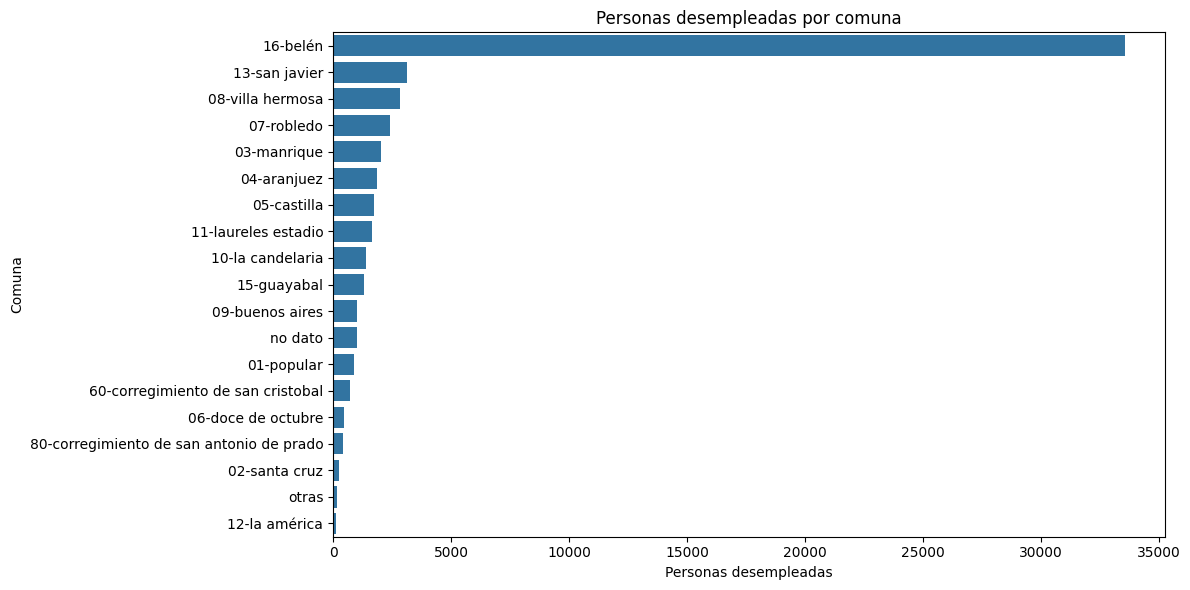

In [ ]:
# Ahora empezamos a analizar graficas y variables de correlación.
# Por ejemplo analizaremos las zonas con mayor desempleo en el Valle de Aburrá
# Cambiamos la orientacion del barplot

desempleados = df[df['empleado'] == 'no']
plt.figure(figsize=(12,6))
sns.countplot(data=desempleados, y='comuna_ciudadano', order=desempleados['comuna_ciudadano'].value_counts().index)
plt.title('Personas desempleadas por comuna')
plt.ylabel('Comuna')
plt.xlabel('Personas desempleadas')
plt.tight_layout()
plt.show()

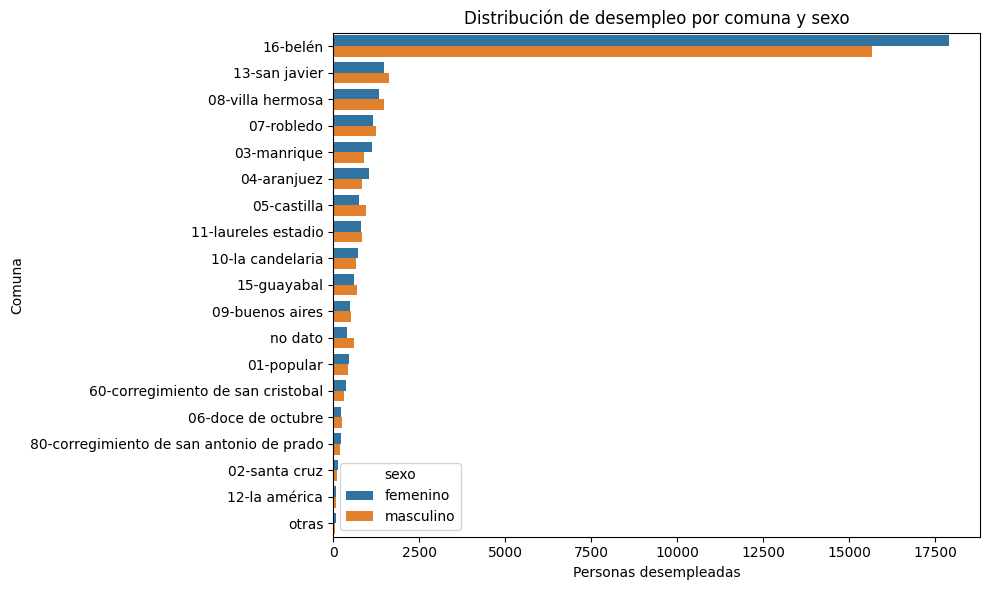

In [ ]:
# Analisis multivariado
# Analisis de gráfico de barras agrupadas para el desempleo por comuna y sexo
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['empleado'] == 'no'], y='comuna_ciudadano', hue='sexo', order=df['comuna_ciudadano'].value_counts().index)
plt.title('Distribución de desempleo por comuna y sexo')
plt.ylabel('Comuna')
plt.xlabel('Personas desempleadas')
plt.tight_layout()
plt.show()

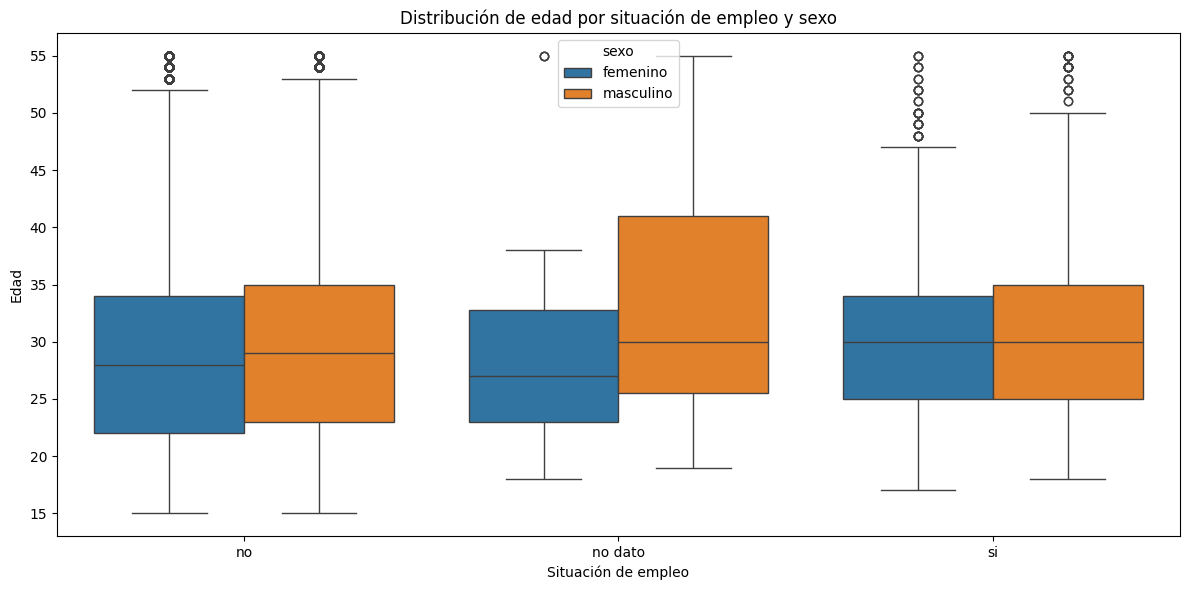

In [ ]:
# Análisis de caja de bigotes por situación de empleo y sexo según la edad
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='empleado', y='edad', hue='sexo')
plt.title('Distribución de edad por situación de empleo y sexo')
plt.ylabel('Edad')
plt.xlabel('Situación de empleo')
plt.tight_layout()
plt.show()

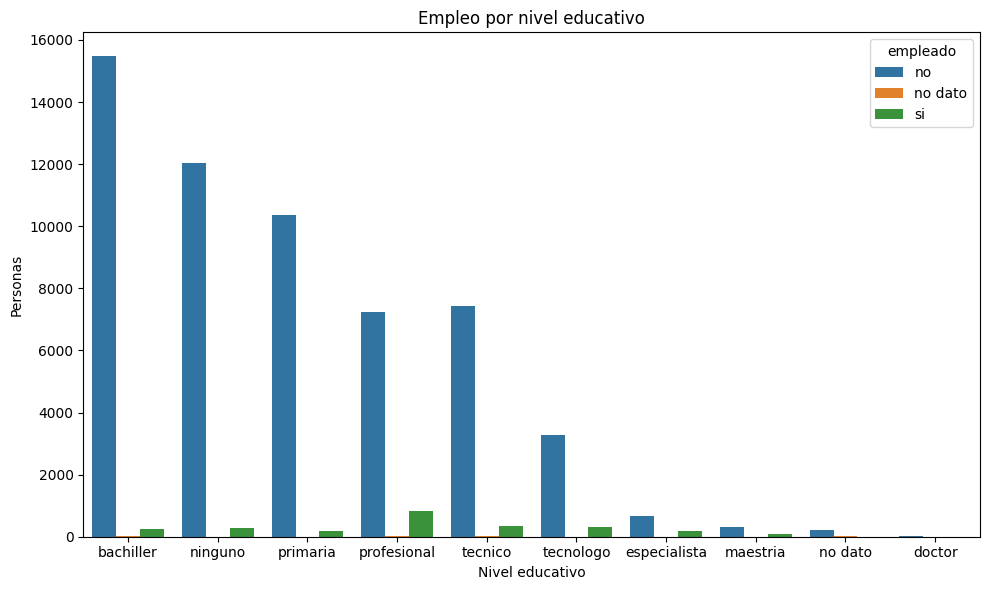

In [ ]:
# Vamos a analizar si el nivel educativo influye en el desempleo

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='nivel_escolaridad', hue='empleado', order=df['nivel_escolaridad'].value_counts().index)
plt.ylabel('Personas')
plt.xlabel('Nivel educativo')
plt.title('Empleo por nivel educativo')
plt.tight_layout()
plt.show()

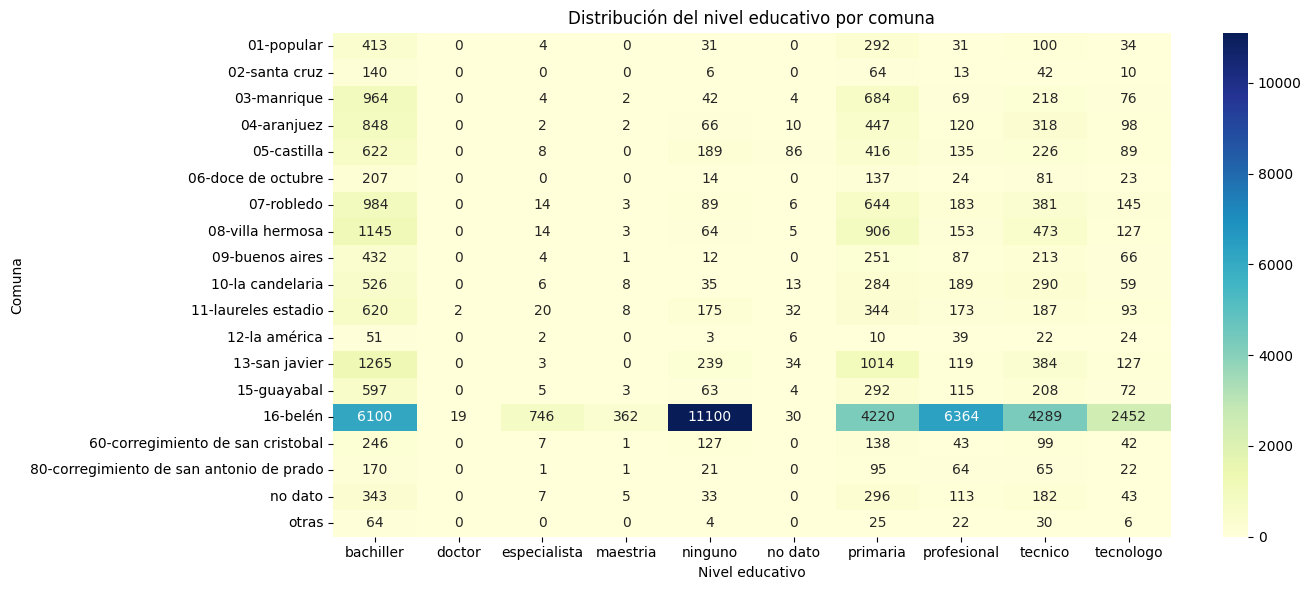

In [ ]:
# Analizamos con un mapa de calor el nivel de escolaridad por comuna

tabla = pd.crosstab(df['comuna_ciudadano'], df['nivel_escolaridad'])

# Mostrarla como heatmap
plt.figure(figsize=(14,6))
sns.heatmap(tabla, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribución del nivel educativo por comuna')
plt.xlabel('Nivel educativo')
plt.ylabel('Comuna')
plt.tight_layout()
plt.show()

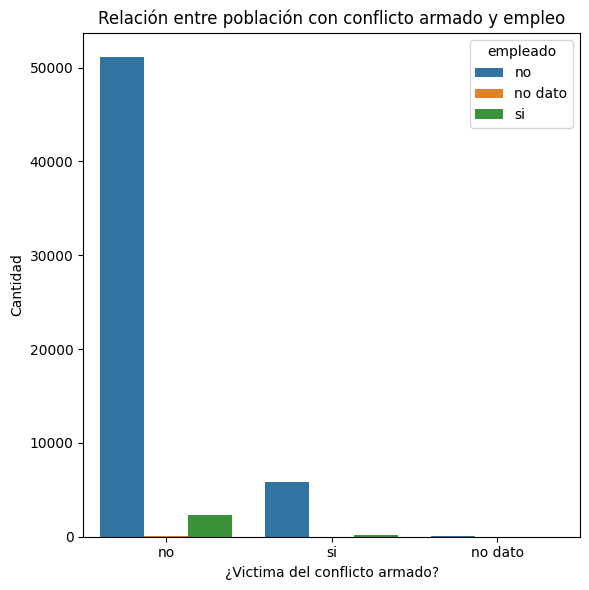

In [ ]:
# Vamos a analizar la población la cual es victima del conflicto armado con la empleabilidad

plt.figure(figsize=(6,6))
sns.countplot(data=df, x='victima', hue='empleado')
plt.title('Relación entre población con conflicto armado y empleo')
plt.xlabel('¿Victima del conflicto armado?')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

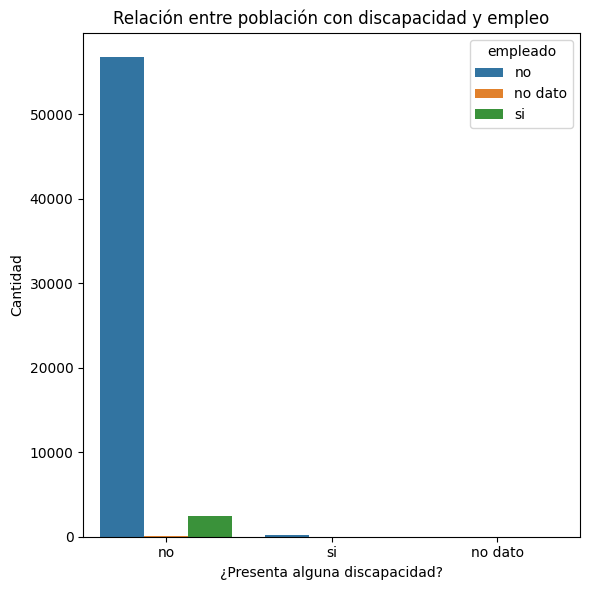

In [ ]:
# Vamos a analizar la población con discapacidad respecto al empleo

plt.figure(figsize=(6,6))
sns.countplot(data=df, x='discapacidad', hue='empleado')
plt.title('Relación entre población con discapacidad y empleo')
plt.xlabel('¿Presenta alguna discapacidad?')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

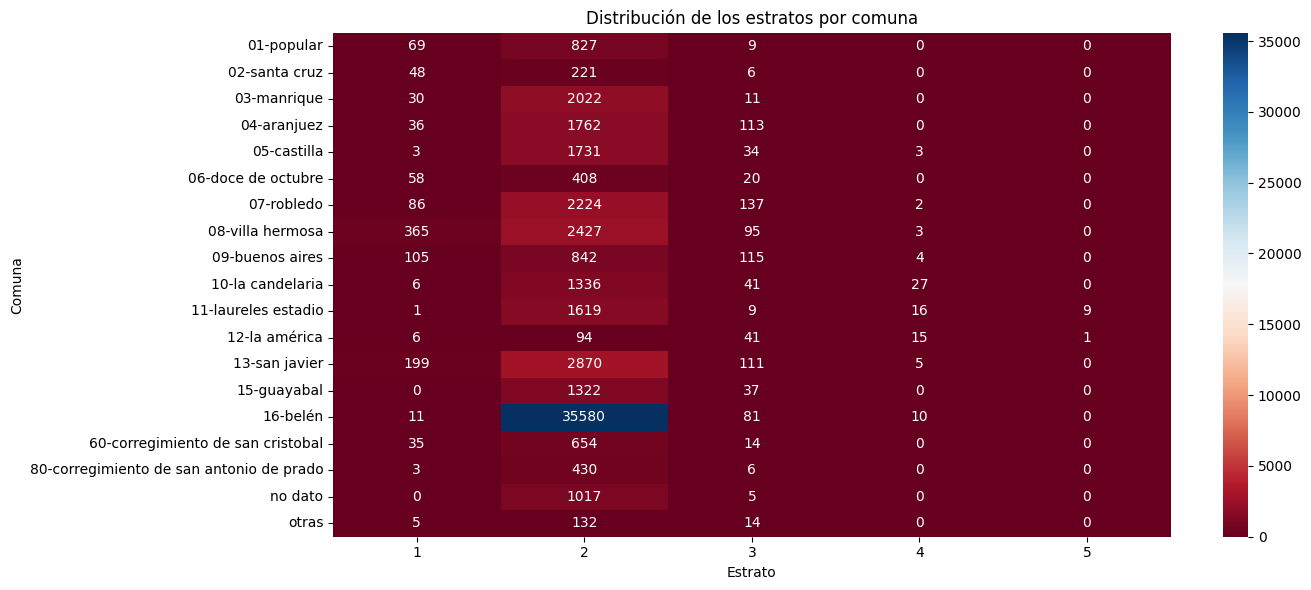

In [ ]:
# Analizamos con un mapa de calor entre el estrato y la comuna para observar la disttribución de como se encuentran ubicadas las personas

tabla = pd.crosstab(df['comuna_ciudadano'], df['estrato'])

# Mostrarla como heatmap
plt.figure(figsize=(14,6))
sns.heatmap(tabla, annot=True, fmt='d', cmap='RdBu')
plt.title('Distribución de los estratos por comuna')
plt.xlabel('Estrato')
plt.ylabel('Comuna')
plt.tight_layout()
plt.show()